In [8]:
%pip install tensorflow-cpu

Note: you may need to restart the kernel to use updated packages.


In [19]:
import tensorflow as tf
print(tf.__version__)


2.19.0


In [13]:
%pip install pandas numpy matplotlib seaborn tqdm  scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [51]:
train_dir = 'train'
test_dir = 'test'

In [52]:
# Import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from tqdm.auto  import tqdm

warnings.filterwarnings('ignore')

# Remove %matplotlib inline, it's not needed, VS Code handles it automatically.
# %matplotlib inline (REMOVE in VS Code Jupyter!)

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img  # corrected keras.preprocessing
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from sklearn.preprocessing import LabelEncoder


In [53]:
def load_dataset(directory):
    images = []
    labels = []
    for label in os.listdir(directory):
        label_dir = os.path.join(directory, label)
        if not os.path.isdir(label_dir):
            continue
        for filename in tqdm(os.listdir(label_dir), desc=f'Loading {label}'):
            image_path = os.path.join(label_dir, filename)
            try:
                images.append(image_path)
                labels.append(label)
            except Exception as e:
                print(f"Error loading {image_path}: {e}")
                continue
        print(label, "Completed")
    return images, labels


In [54]:
# Create train DataFrame
train = pd.DataFrame()
train['image_path'], train['label'] = load_dataset(train_dir)

# Shuffle the dataset
train = train.sample(frac=1, random_state=42).reset_index(drop=True)
train.head()


Loading angry: 100%|██████████| 3995/3995 [00:00<00:00, 229430.74it/s]


angry Completed


Loading disgust: 100%|██████████| 436/436 [00:00<00:00, 144940.68it/s]


disgust Completed


Loading fear: 100%|██████████| 4097/4097 [00:00<00:00, 230658.57it/s]


...

Loading sad: 100%|██████████| 4830/4830 [00:00<00:00, 203390.31it/s]


sad Completed


Loading surprise: 100%|██████████| 3171/3171 [00:00<00:00, 184416.78it/s]


surprise Completed


,image_path,label
0,train\fear\Training_22695598.jpg,fear
1,train\happy\Training_47178464.jpg,happy
2,train\surprise\Training_76747047.jpg,surprise
3,train\fear\Training_22757966.jpg,fear
4,train\surprise\Training_78696030.jpg,surprise


In [55]:

# Load test dataset
test = pd.DataFrame()
test['image_path'], test['label'] = load_dataset(test_dir)

Loading angry: 100%|██████████| 958/958 [00:00<00:00, 235488.67it/s]


angry Completed


Loading disgust: 100%|██████████| 111/111 [00:00<00:00, 110875.86it/s]


disgust Completed


Loading fear: 100%|██████████| 1024/1024 [00:00<00:00, 235108.79it/s]


...

neutral Completed


Loading sad: 100%|██████████| 1247/1247 [00:00<00:00, 249572.80it/s]


sad Completed


Loading surprise: 100%|██████████| 831/831 [00:00<00:00, 179969.36it/s]

surprise Completed


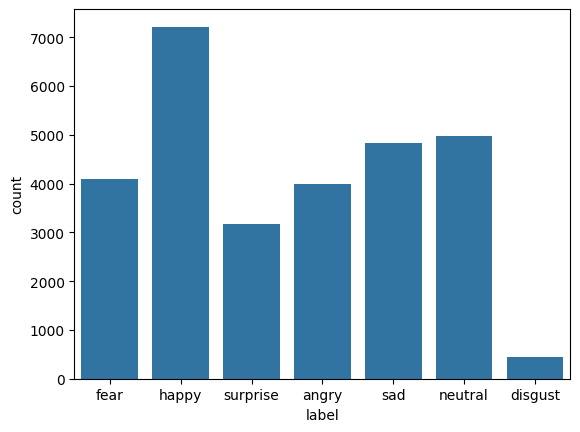

In [56]:
# Visualizations
sns.countplot(x='label', data=train)
plt.show()

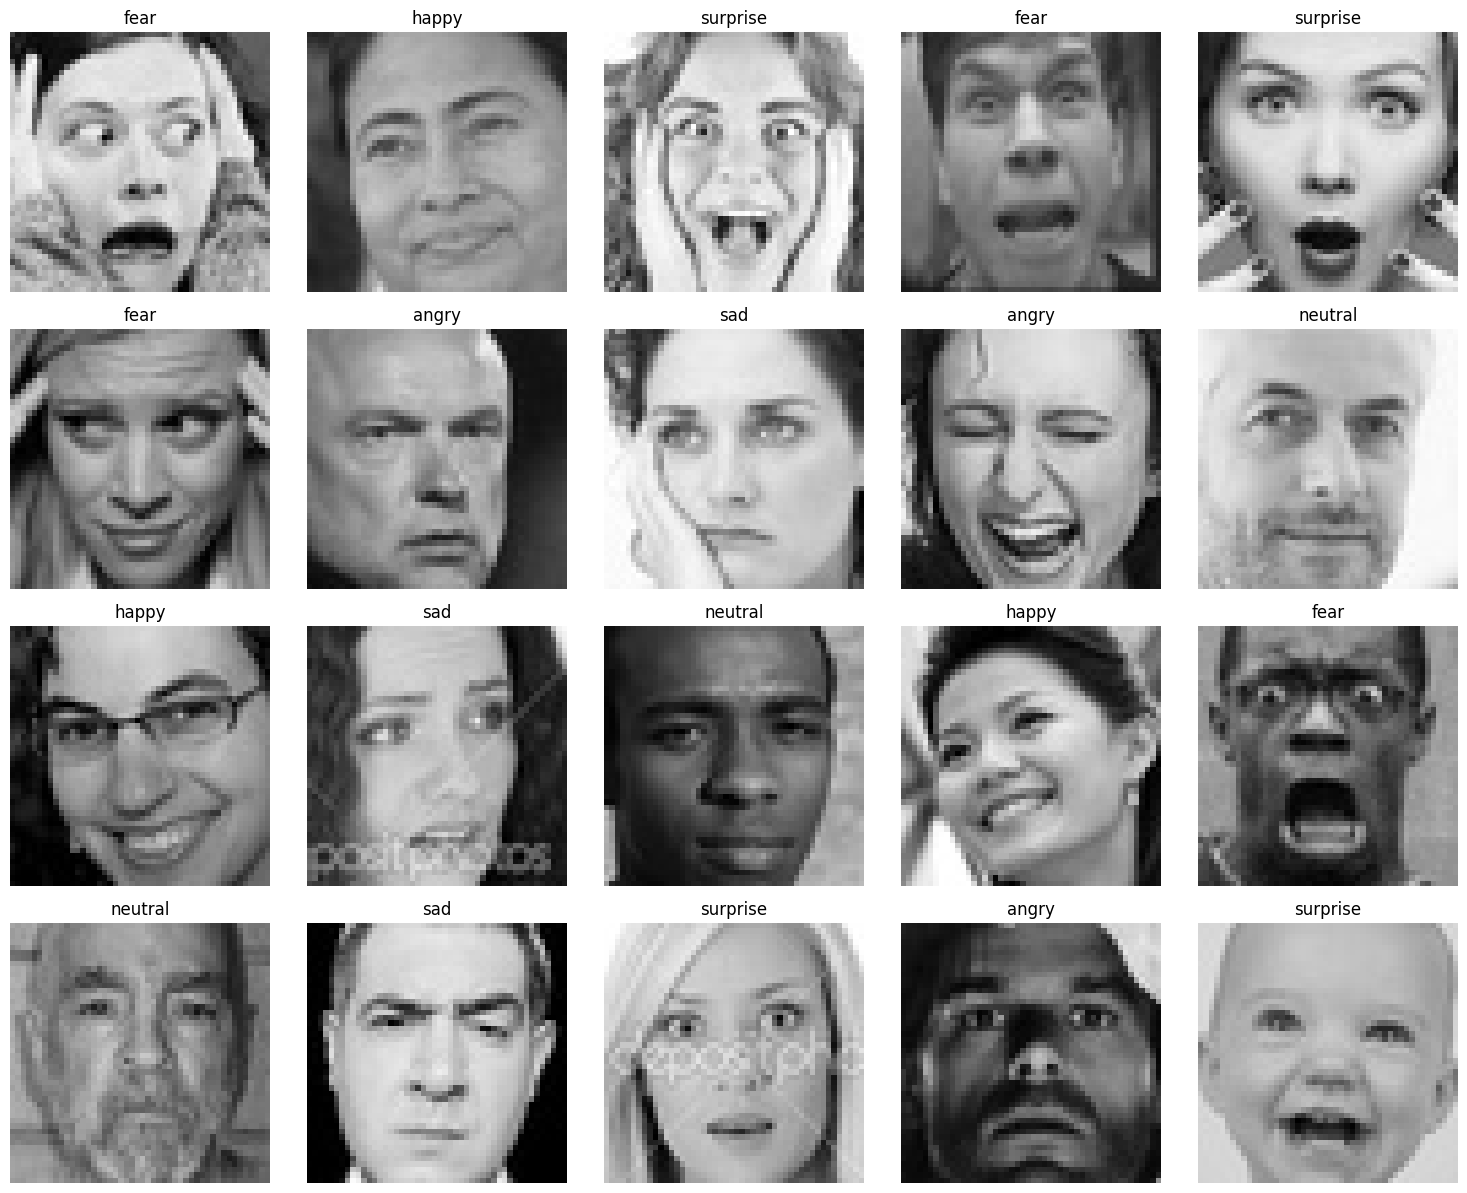

In [57]:
# Display grid of images
plt.figure(figsize=(15, 15))
files = train.iloc[0:20]

for idx, row in files.iterrows():
    file, label = row['image_path'], row['label']
    plt.subplot(5, 5, idx % 25 + 1)
    img = load_img(file)
    plt.imshow(img)
    plt.axis('off')
    plt.title(label)

plt.tight_layout()
plt.show()

In [58]:
# Function to extract features
def extract_features(images):
    features = []
    for image in tqdm(images, desc='Extracting features'):
        img = load_img(image, color_mode='grayscale', target_size=(48, 48))
        img = np.array(img)
        features.append(img)
    features = np.array(features)
    features = features.reshape(len(features), 48, 48, 1)
    return features

In [59]:

# Extract features
train_features = extract_features(train['image_path'])

Extracting features: 100%|██████████| 28709/28709 [03:37<00:00, 132.14it/s]


In [60]:
test_features = extract_features(test['image_path'])

Extracting features: 100%|██████████| 7178/7178 [01:27<00:00, 82.03it/s] 


In [61]:
# Normalize the features
x_train = train_features / 255.0
x_test = test_features / 255.0

In [62]:
# Encode labels
le = LabelEncoder()
y_train = le.fit_transform(train['label'])
y_test = le.transform(test['label'])

In [63]:
# One-hot encode the labels
y_train = to_categorical(y_train, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

In [15]:
# Model configuration
input_shape = (48, 48, 1)
output_class = 7

Building the model

In [35]:
model = Sequential([
    Conv2D(128, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),

    Conv2D(256, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),

    Conv2D(512, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),

    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.4),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(output_class, activation='softmax')
])

In [39]:
# Define callbacks
callbacks = [
    ModelCheckpoint('CNN_fer2013_best_model.h5',
                    monitor='val_accuracy',
                    save_best_only=True,
                    mode='max'),

    ReduceLROnPlateau(monitor='val_loss',
                      factor=0.1,
                      patience=5,
                      min_lr=0.00001),

    EarlyStopping(monitor='val_loss',
                  patience=15,
                  restore_best_weights=True)
]

# Train the model
history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=128,
    epochs=70,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/70
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2470 - loss: 1.8236

225/225 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.2470 - loss: 1.8235 - val_accuracy: 0.2523 - val_loss: 1.8020 - learning_rate: 0.0010
Epoch 2/70
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2583 - loss: 1.7869

225/225 ━━━━━━━━━━━━━━━━━━━━ 370s 2s/step - accuracy: 0.2583 - loss: 1.7868 - val_accuracy: 0.3093 - val_loss: 1.6881 - learning_rate: 0.0010
Epoch 3/70
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3209 - loss: 1.6823

225/225 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.3210 - loss: 1.6822 - val_accuracy: 0.3892 - val_loss: 1.5327 - learning_rate: 0.0010
Epoch 4/70
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3771 - loss: 1.5726

225/225 ━━━━━━━━━━━━━━━━━━━━ 357s 2s/step - accuracy: 0.3772 - loss: 1.5725 - val_accuracy: 0.4519 - val_loss: 1.4347 - learning_rate: 0.0010
Epoch 5/70
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4204 - loss: 1.4849

...

225/225 ━━━━━━━━━━━━━━━━━━━━ 393s 2s/step - accuracy: 0.6482 - loss: 0.9321 - val_accuracy: 0.6211 - val_loss: 1.0125 - learning_rate: 1.0000e-04
Epoch 64/70
225/225 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.6512 - loss: 0.9341 - val_accuracy: 0.6205 - val_loss: 1.0117 - learning_rate: 1.0000e-04
Epoch 65/70
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6566 - loss: 0.9260

225/225 ━━━━━━━━━━━━━━━━━━━━ 390s 2s/step - accuracy: 0.6566 - loss: 0.9260 - val_accuracy: 0.6232 - val_loss: 1.0103 - learning_rate: 1.0000e-04
Epoch 66/70
225/225 ━━━━━━━━━━━━━━━━━━━━ 385s 2s/step - accuracy: 0.6496 - loss: 0.9350 - val_accuracy: 0.6230 - val_loss: 1.0087 - learning_rate: 1.0000e-04
Epoch 67/70
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6587 - loss: 0.9098

225/225 ━━━━━━━━━━━━━━━━━━━━ 410s 2s/step - accuracy: 0.6587 - loss: 0.9098 - val_accuracy: 0.6233 - val_loss: 1.0079 - learning_rate: 1.0000e-04
Epoch 68/70
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6616 - loss: 0.9141

225/225 ━━━━━━━━━━━━━━━━━━━━ 396s 2s/step - accuracy: 0.6616 - loss: 0.9141 - val_accuracy: 0.6245 - val_loss: 1.0091 - learning_rate: 1.0000e-04
Epoch 69/70
225/225 ━━━━━━━━━━━━━━━━━━━━ 458s 2s/step - accuracy: 0.6576 - loss: 0.9183 - val_accuracy: 0.6232 - val_loss: 1.0095 - learning_rate: 1.0000e-04
Epoch 70/70
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6582 - loss: 0.9099

225/225 ━━━━━━━━━━━━━━━━━━━━ 389s 2s/step - accuracy: 0.6582 - loss: 0.9099 - val_accuracy: 0.6254 - val_loss: 1.0051 - learning_rate: 1.0000e-04


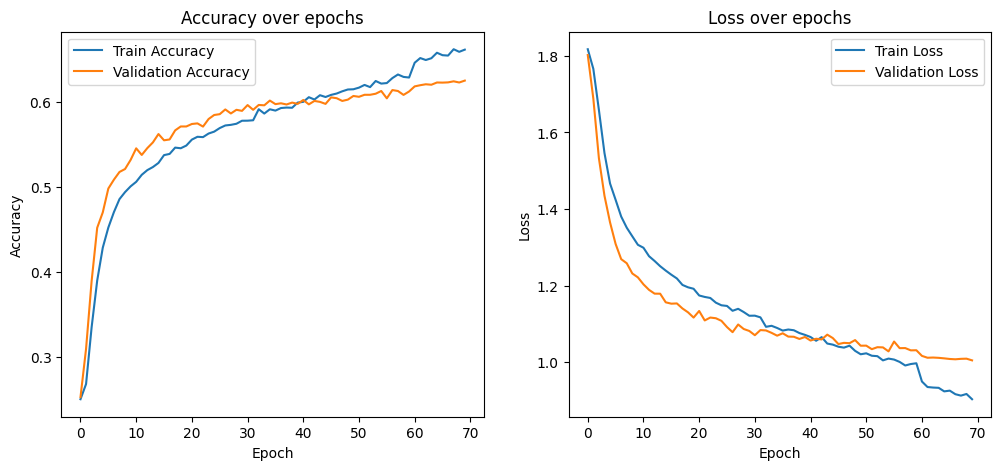

In [40]:
# Plot accuracy and loss
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [ ]:
# Save the final model (optional)
model.save('CNN.fer2013_final_model.h5')


In [42]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 29s 127ms/step - accuracy: 0.5729 - loss: 1.1164
Test Accuracy: 62.54%
Test Loss: 1.0051


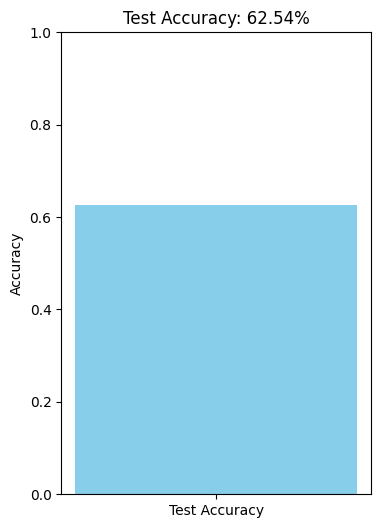

In [ ]:
# Plot the Test Accuracy as a bar chart
plt.figure(figsize=(4,6))
plt.bar(['Test Accuracy'], [test_accuracy], color='skyblue')
plt.ylim(0, 1)
plt.title(f"Test Accuracy: {test_accuracy*100:.2f}%")
plt.ylabel('Accuracy')
plt.show()

In [44]:
# Predict classes for the test set
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Get index of highest probability
y_true = np.argmax(y_test, axis=1)  # True labels


225/225 ━━━━━━━━━━━━━━━━━━━━ 28s 123ms/step


<Figure size 1000x800 with 0 Axes>

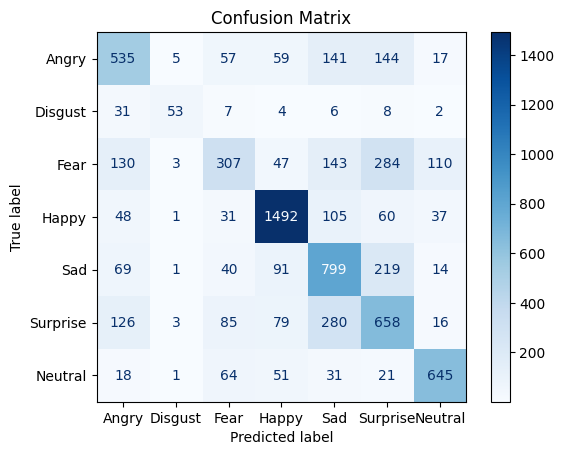

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Define class names (for FER2013 dataset)
class_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Plot
plt.figure(figsize=(10,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix')
plt.show()


In [32]:
from tensorflow.keras.models import load_model

# Load the full saved model
model = load_model('CNN.fer2013_final_model.h5')

FileNotFoundError: [Errno 2] No such file or directory: 'testtt/frodosad.jpeg'

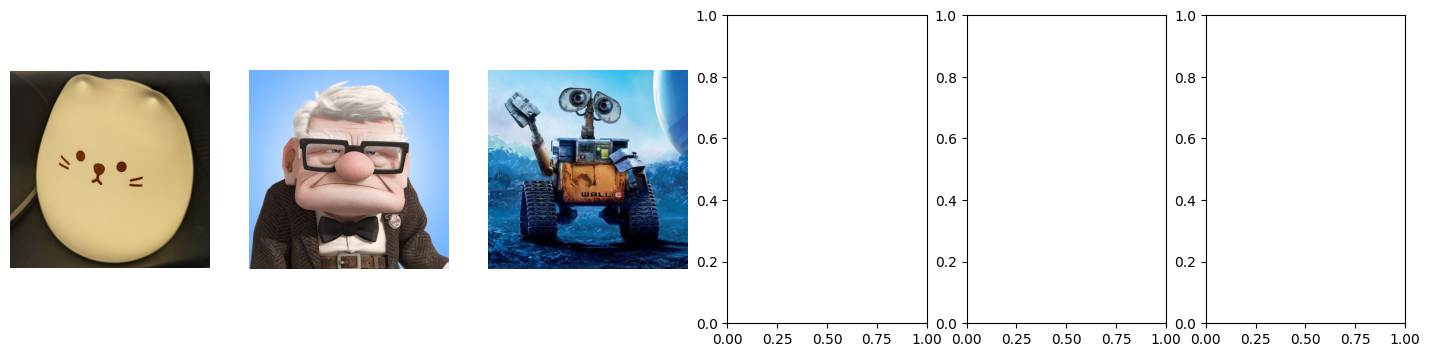

In [33]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from PIL import Image
import matplotlib.pyplot as plt

# Global settings
img_size = 48
class_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Prediction function
def predict_custom(img_path):
    img = keras.preprocessing.image.load_img(img_path, target_size=(img_size, img_size), color_mode="grayscale")
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) / 255.0  # normalize
    pred = model.predict(img_array, verbose=0)
    pred_class = np.argmax(pred, axis=1)
    return class_labels[pred_class[0]]
    # To include confidence: return f"{class_labels[pred_class[0]]} ({pred[0][pred_class[0]]:.2f})"

# List of image paths (fixed using raw strings or forward slashes)
images = [
    'testtt/cat.jpg',
    'testtt/carl.jpeg',
    'testtt/walle.jpg',
    'testtt/frodosad.jpeg',
    'testtt/gandalfsurprised.jpg',
    'testtt/angrylogan.jpg'
]

# Plot predictions
fig, axarr = plt.subplots(1, len(images))
fig.set_size_inches((18, 4))

for i, img_path in enumerate(images):
    img = Image.open(img_path).convert("RGB")
    axarr[i].imshow(img)
    axarr[i].set_xlabel(predict_custom(img_path))
    axarr[i].axis('off')

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
Predicted Emotion: surprise


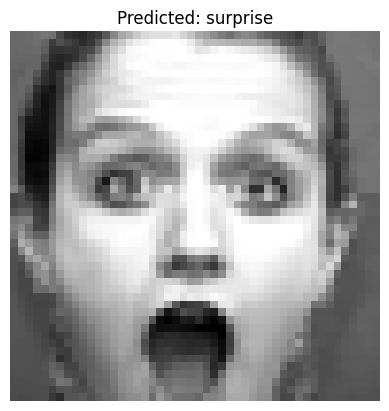

In [49]:
from keras.preprocessing import image

# Path to your test image
img_path = 'test.png'  # <<< CHANGE THIS

# Load and preprocess the image
img = load_img(img_path, color_mode='grayscale', target_size=(48, 48))
img_array = np.array(img)
img_array = img_array / 255.0  # Normalize
img_array = img_array.reshape(1, 48, 48, 1)  # Reshape for prediction

# Predict
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

# Decode the label
class_labels = le.classes_  # the classes from LabelEncoder
predicted_label = class_labels[predicted_class]

print(f"Predicted Emotion: {predicted_label}")

# Show the image
plt.imshow(img, cmap='gray')
plt.title(f"Predicted: {predicted_label}")
plt.axis('off')
plt.show()


In [8]:
%pip install opencv-python

In [9]:
pip install opencv-python-headless

Note: you may need to restart the kernel to use updated packages.


In [16]:
from tensorflow.keras.models import load_model

# Load the full saved model
model = load_model('CNN.fer2013_final_model.h5')


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [4]:
import cv2 
from keras.preprocessing.image import img_to_array
import numpy as np

# Load the trained model
model.load_weights('CNN.fer2013_final_model.h5')  # or your saved model path

# Load Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def predict_emotion(image_path):
    # Load the image
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect faces in the image
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    if len(faces) == 0:
        print("!No face detected!")
        return

    # Assuming the first detected face
    (x, y, w, h) = faces[0]

    # Crop the face
    face = gray[y:y+h, x:x+w]

    # Resize to 48x48
    face = cv2.resize(face, (48, 48))

    # Preprocess for model
    face = face.astype('float') / 255.0
    face = img_to_array(face)
    face = np.expand_dims(face, axis=0)
    
    # Predict emotion
    prediction = model.predict(face)
    class_idx = np.argmax(prediction)
    emotion = le.inverse_transform([class_idx])[0]

    print(f"Predicted Emotion: {emotion}")

    # Show the cropped face
    plt.imshow(face.squeeze(), cmap='gray')
    plt.title(f"Predicted: {emotion}")
    plt.axis('off')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 860ms/step
Predicted Emotion: surprise


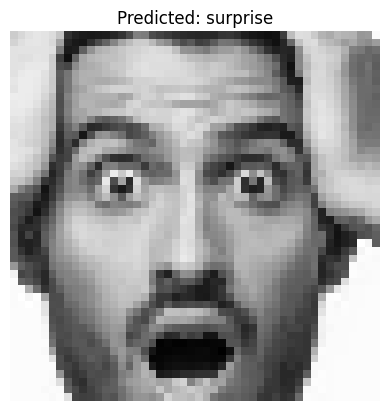

In [17]:
predict_emotion('test.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
Predicted Emotion: happy


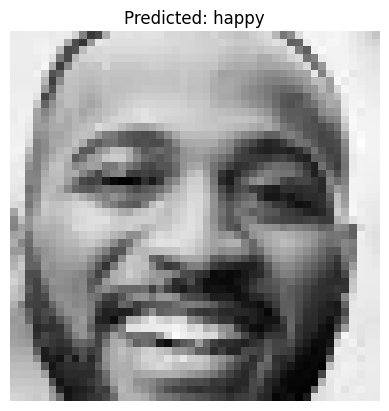

In [19]:
predict_emotion('images.jpeg')

In [20]:
predict_emotion('imag.jpeg')

!No face detected!


In [20]:
from sklearn.preprocessing import LabelEncoder

# Define the actual emotion labels used in your dataset
emotion_labels = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

# Fit the LabelEncoder
le = LabelEncoder()
le.fit(emotion_labels)


LabelEncoder()

In [21]:
%pip install mediapipe

Note: you may need to restart the kernel to use updated packages.


In [34]:
from tensorflow.keras.models import load_model

# Load the full saved model
model = load_model('CNN.fer2013_final_model.h5')


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
from keras.preprocessing.image import img_to_array
import matplotlib.pyplot as plt

# Load the trained model
model.load_weights('CNN.fer2013_final_model.h5')  # Remplace par ton chemin correct

# Initialize Mediapipe face detector
mp_face_detection = mp.solutions.face_detection
mp_drawing = mp.solutions.drawing_utils


# Create the face detection object
face_detection = mp_face_detection.FaceDetection(model_selection=0, min_detection_confidence=0.5)

def predict_emotion(image_path):
    # Load the image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Detect faces
    results = face_detection.process(img_rgb)

    if not results.detections:
        print("!No face detected!")
        return
    
    # Take the first detected face
    detection = results.detections[0]
    bboxC = detection.location_data.relative_bounding_box
    
    ih, iw, _ = img.shape
    x = int(bboxC.xmin * iw)
    y = int(bboxC.ymin * ih)
    w = int(bboxC.width * iw)
    h = int(bboxC.height * ih)
    
    # Crop the face
    face = img[y:y+h, x:x+w]
    
    if face.size == 0:
        print("! Detected face is empty!")
        return

    # Convert to grayscale
    face = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
    
    # Resize to 48x48
    face = cv2.resize(face, (48, 48))
    
    # Preprocess for model
    face = face.astype('float') / 255.0
    face = img_to_array(face)
    face = np.expand_dims(face, axis=0)

    # Predict emotion
    prediction = model.predict(face)
    class_idx = np.argmax(prediction)
    emotion = le.inverse_transform([class_idx])[0]

    print(f"Predicted Emotion: {emotion}")

    # Show the cropped face
    plt.imshow(face.squeeze(), cmap='gray')
    plt.title(f"Predicted: {emotion}")
    plt.axis('off')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Predicted Emotion: angry


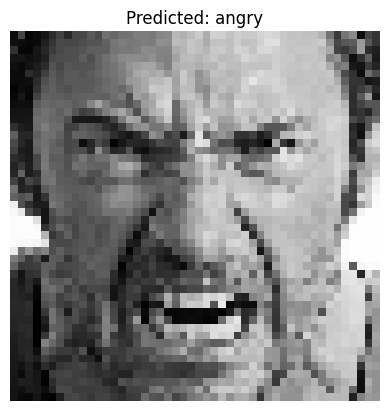

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Predicted Emotion: sad


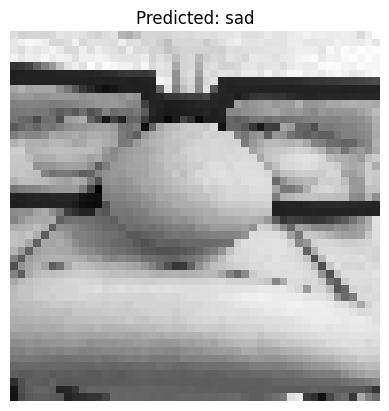

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Predicted Emotion: neutral


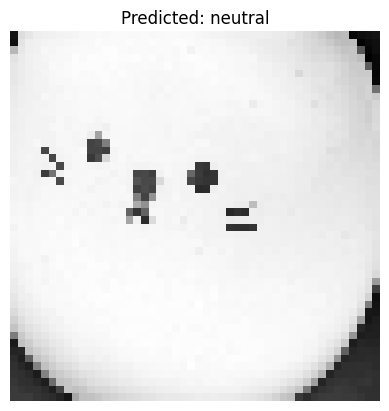

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Predicted Emotion: sad


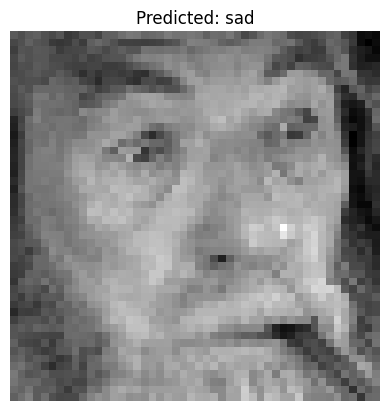

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
Predicted Emotion: surprise


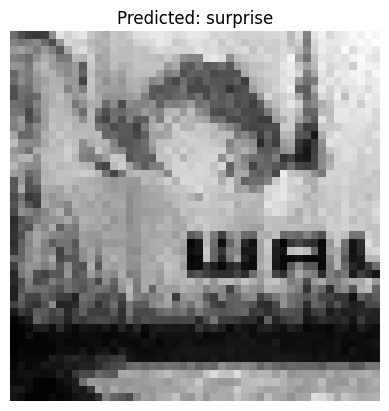

In [40]:
predict_emotion('angrylogan.jpg')
predict_emotion('carl.jpeg')
predict_emotion('cat.jpg')
predict_emotion('gandalfsurprised.jpg')
predict_emotion('walle.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
Predicted Emotion: fear


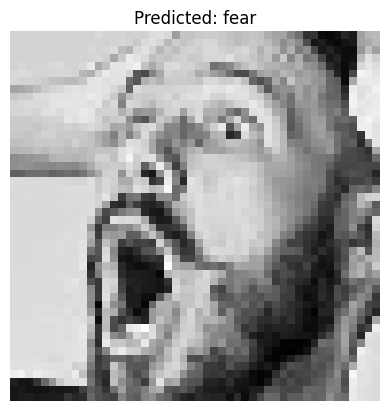

In [20]:
predict_emotion('2test.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted Emotion: fear


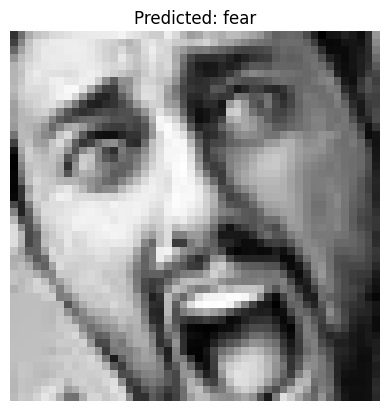

In [21]:
predict_emotion('images.jpeg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted Emotion: angry


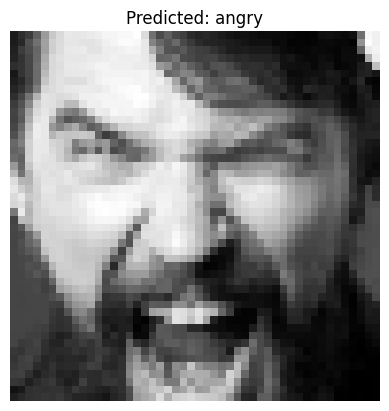

In [24]:
predict_emotion('angry.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted Emotion: sad


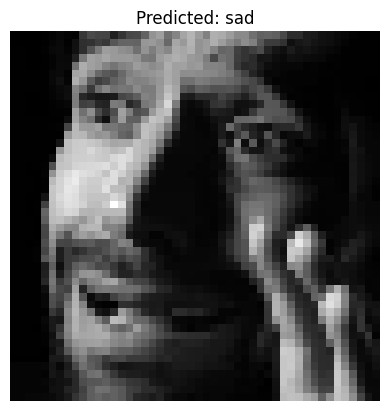

In [25]:
predict_emotion('ttte.webp')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
Predicted Emotion: happy


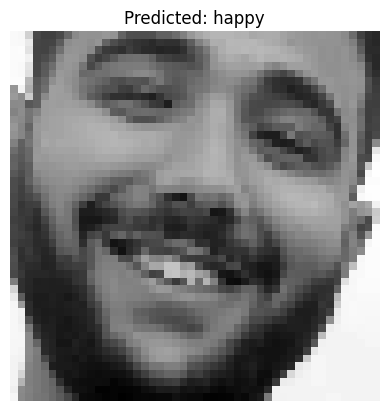

In [24]:
predict_emotion('55ff.jpg')

####CNN _ Data augmentaion 


In [65]:
from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator

In [70]:
# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)

In [71]:

# Model definition
model = Sequential([
    Conv2D(128, kernel_size=(3, 3), activation='relu', input_shape=(48, 48, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),

    Conv2D(256, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),

    Conv2D(512, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),

    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.4),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(7, activation='softmax')
])

# Callbacks
callbacks = [
    ModelCheckpoint('CNN_fer2013_best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=0.00001),
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
]

In [72]:
# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [75]:
# Train the model with data augmentation
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=100,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.3150 - loss: 1.6944

449/449 ━━━━━━━━━━━━━━━━━━━━ 326s 724ms/step - accuracy: 0.3151 - loss: 1.6943 - val_accuracy: 0.4062 - val_loss: 1.5102 - learning_rate: 0.0010
Epoch 2/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.3658 - loss: 1.6018

449/449 ━━━━━━━━━━━━━━━━━━━━ 324s 722ms/step - accuracy: 0.3658 - loss: 1.6018 - val_accuracy: 0.4136 - val_loss: 1.4924 - learning_rate: 0.0010
Epoch 3/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - accuracy: 0.3990 - loss: 1.5507

449/449 ━━━━━━━━━━━━━━━━━━━━ 350s 779ms/step - accuracy: 0.3990 - loss: 1.5506 - val_accuracy: 0.4606 - val_loss: 1.3986 - learning_rate: 0.0010
Epoch 4/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 340s 758ms/step - accuracy: 0.4092 - loss: 1.5202 - val_accuracy: 0.4603 - val_loss: 1.3680 - learning_rate: 0.0010
Epoch 5/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - accuracy: 0.4229 - loss: 1.4884

449/449 ━━━━━━━━━━━━━━━━━━━━ 339s 755ms/step - accuracy: 0.4229 - loss: 1.4884 - val_accuracy: 0.4908 - val_loss: 1.3360 - learning_rate: 0.0010
Epoch 6/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 341s 759ms/step - accuracy: 0.4367 - loss: 1.4627 - val_accuracy: 0.4847 - val_loss: 1.3205 - learning_rate: 0.0010
Epoch 7/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 811ms/step - accuracy: 0.4342 - loss: 1.4630

...

449/449 ━━━━━━━━━━━━━━━━━━━━ 465s 1s/step - accuracy: 0.5329 - loss: 1.2347 - val_accuracy: 0.5782 - val_loss: 1.1286 - learning_rate: 1.0000e-04
Epoch 52/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 461s 1s/step - accuracy: 0.5261 - loss: 1.2451 - val_accuracy: 0.5779 - val_loss: 1.1254 - learning_rate: 1.0000e-04
Epoch 53/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 383s 853ms/step - accuracy: 0.5304 - loss: 1.2355 - val_accuracy: 0.5777 - val_loss: 1.1258 - learning_rate: 1.0000e-04
Epoch 54/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 358s 796ms/step - accuracy: 0.5214 - loss: 1.2475 - val_accuracy: 0.5773 - val_loss: 1.1268 - learning_rate: 1.0000e-04
Epoch 55/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.5325 - loss: 1.2377

449/449 ━━━━━━━━━━━━━━━━━━━━ 335s 747ms/step - accuracy: 0.5325 - loss: 1.2377 - val_accuracy: 0.5784 - val_loss: 1.1249 - learning_rate: 1.0000e-04
Epoch 56/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 317s 707ms/step - accuracy: 0.5298 - loss: 1.2413 - val_accuracy: 0.5773 - val_loss: 1.1247 - learning_rate: 1.0000e-04
Epoch 57/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 315s 702ms/step - accuracy: 0.5341 - loss: 1.2412 - val_accuracy: 0.5770 - val_loss: 1.1209 - learning_rate: 1.0000e-04
Epoch 58/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 317s 707ms/step - accuracy: 0.5285 - loss: 1.2363 - val_accuracy: 0.5759 - val_loss: 1.1262 - learning_rate: 1.0000e-04
Epoch 59/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 315s 701ms/step - accuracy: 0.5237 - loss: 1.2511 - val_accuracy: 0.5776 - val_loss: 1.1271 - learning_rate: 1.0000e-04
Epoch 60/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 316s 703ms/step - accuracy: 0.5310 - loss: 1.2378 - val_accuracy: 0.5759 - val_loss: 1.1242 - learning_rate: 1.0000e-04
Epoch 61/100
449/449 ━━━━━━━━━━━━━━━━━━━━

449/449 ━━━━━━━━━━━━━━━━━━━━ 314s 698ms/step - accuracy: 0.5321 - loss: 1.2355 - val_accuracy: 0.5814 - val_loss: 1.1193 - learning_rate: 1.0000e-04
Epoch 62/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 313s 697ms/step - accuracy: 0.5334 - loss: 1.2252 - val_accuracy: 0.5782 - val_loss: 1.1209 - learning_rate: 1.0000e-04
Epoch 63/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.5304 - loss: 1.2367

449/449 ━━━━━━━━━━━━━━━━━━━━ 313s 697ms/step - accuracy: 0.5304 - loss: 1.2367 - val_accuracy: 0.5822 - val_loss: 1.1231 - learning_rate: 1.0000e-04
Epoch 64/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 321s 714ms/step - accuracy: 0.5329 - loss: 1.2371 - val_accuracy: 0.5797 - val_loss: 1.1209 - learning_rate: 1.0000e-04
Epoch 65/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 317s 705ms/step - accuracy: 0.5342 - loss: 1.2314 - val_accuracy: 0.5818 - val_loss: 1.1257 - learning_rate: 1.0000e-04
Epoch 66/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 314s 699ms/step - accuracy: 0.5309 - loss: 1.2296 - val_accuracy: 0.5772 - val_loss: 1.1233 - learning_rate: 1.0000e-04
Epoch 67/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 314s 699ms/step - accuracy: 0.5366 - loss: 1.2257 - val_accuracy: 0.5804 - val_loss: 1.1194 - learning_rate: 1.0000e-05
Epoch 68/100
 53/449 ━━━━━━━━━━━━━━━━━━━━ 4:39 706ms/step - accuracy: 0.5340 - loss: 1.2705

KeyboardInterrupt: 

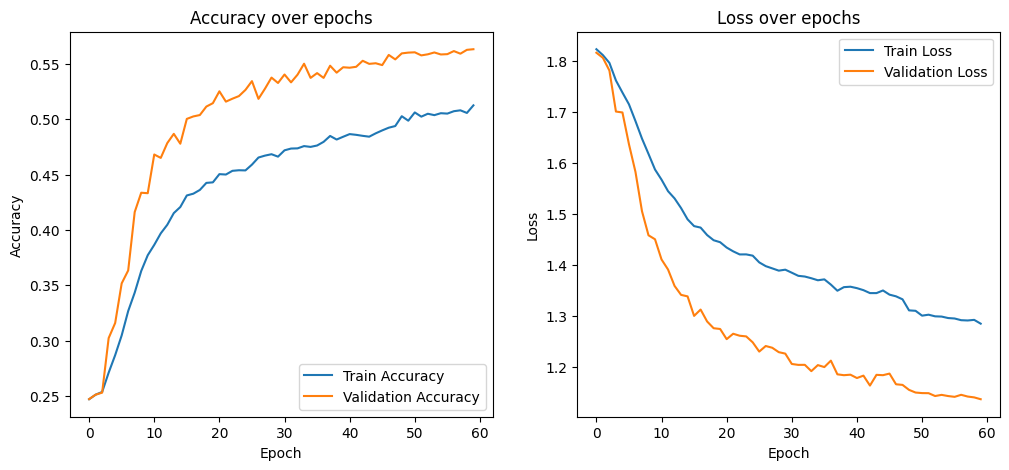

In [76]:
# Plot accuracy and loss
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [82]:
# Load the pre-trained model
model = load_model('Resnet_model.keras')
fer_test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'test', 
    target_size=(224, 224), 
    class_mode='categorical', 
    batch_size=64,
    shuffle=False
)

# Évaluer la performance
loss, acc = model.evaluate(fer_test_generator)
print(f"Accuracy sur FER2013 : {acc:.2f}")


Found 7178 images belonging to 7 classes.
113/113 ━━━━━━━━━━━━━━━━━━━━ 1659s 14s/step - accuracy: 0.6200 - loss: 1.0265
Accuracy sur FER2013 : 0.65


In [1]:
class_names = ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sadness', 'surprise']
class_ids = {name: idx for idx, name in enumerate(class_names)}
# Usage: model.predict() outputs will follow this order